# EE 344 Project - Robot Execution Failure Detection via Unsupervised Learning

**Ye Cao** | Winter 2026 | EE 344  

---

**Dataset:** [Robot Execution Failures](https://archive.ics.uci.edu/dataset/138/robot+execution+failures) from the UCI ML Repository.  
I'm working with LP4 (117 samples, 3 classes) and LP5 (164 samples, 5 classes) - each sample is 15 timesteps of 6 force/torque sensor channels = 90 raw features.

The goal is to see if unsupervised clustering can recover the failure types without ever training on the labels.

## 1. Setup

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.fft import fft

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
)
from sklearn.model_selection import ShuffleSplit
from collections import Counter

import warnings
warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)

CHANNELS = ["Fx", "Fy", "Fz", "Tx", "Ty", "Tz"]
N_TIMESTEPS = 15
N_CHANNELS  = 6

## 2. Data Loading

Upload `lp4.data` and `lp5.data` to Colab (folder icon on the left sidebar) before running this cell. The files have a weird format - each sample starts with a class label line, then 15 lines of 6 sensor readings.

In [7]:
def parse_uci_file(filepath):
    """Parse a UCI Robot Execution Failures .data file."""
    with open(filepath, 'r') as f:
        lines = [line.strip() for line in f if line.strip()]

    X_list, y_list = [], []
    i = 0
    while i < len(lines):
        label = lines[i].strip().rstrip(';').strip()
        i += 1
        sample_ts = []
        for t in range(N_TIMESTEPS):
            row = lines[i].replace(';', ' ').replace('\t', ' ').split()
            values = [int(v) for v in row[:N_CHANNELS]]
            sample_ts.append(values)
            i += 1
        X_list.append(np.array(sample_ts).flatten())
        y_list.append(label)

    X = np.array(X_list)
    X_3d = X.reshape(-1, N_TIMESTEPS, N_CHANNELS)
    return X, y_list, X_3d

X_lp4, y_lp4, X_lp4_3d = parse_uci_file("lp4.data")
X_lp5, y_lp5, X_lp5_3d = parse_uci_file("lp5.data")

# Combine LP4 + LP5
X_all = np.vstack([X_lp4, X_lp5])
y_all = np.array(y_lp4 + y_lp5)
X_all_3d = np.vstack([X_lp4_3d, X_lp5_3d])
phase_labels = np.array(["LP4"] * len(X_lp4) + ["LP5"] * len(X_lp5))

col_names = [f"{ch}_t{t+1:02d}" for t in range(N_TIMESTEPS) for ch in CHANNELS]
df_all = pd.DataFrame(X_all, columns=col_names)
df_all["label"] = y_all
df_all["phase"] = phase_labels

print(f"LP4: {X_lp4.shape[0]} samples, classes = {sorted(set(y_lp4))}")
print(f"LP5: {X_lp5.shape[0]} samples, classes = {sorted(set(y_lp5))}")
print(f"Combined: {X_all.shape[0]} samples x {X_all.shape[1]} features")
print(f"3D shape: {X_all_3d.shape}")
df_all.head()

LP4: 117 samples, classes = ['collision', 'normal', 'obstruction']
LP5: 164 samples, classes = ['bottom_collision', 'bottom_obstruction', 'collision_in_part', 'collision_in_tool', 'normal']
Combined: 281 samples x 90 features
3D shape: (281, 15, 6)


,Fx_t01,Fy_t01,Fz_t01,Tx_t01,Ty_t01,Tz_t01,Fx_t02,Fy_t02,Fz_t02,Tx_t02,...,Ty_t14,Tz_t14,Fx_t15,Fy_t15,Fz_t15,Tx_t15,Ty_t15,Tz_t15,label,phase
0,-2,2,20,5,-6,-1,-2,1,20,5,...,2,0,-2,2,29,3,-6,0,normal,LP4
1,-3,2,22,5,-8,0,-2,2,19,5,...,-8,-1,-3,3,24,4,-8,-1,normal,LP4
2,-2,2,20,5,-6,-1,-2,2,19,5,...,-5,-2,-3,1,3,5,-6,0,normal,LP4
3,-2,2,20,5,-6,-1,-3,1,18,4,...,-10,-1,-2,1,30,5,-5,-1,normal,LP4
4,-2,2,20,4,-7,-1,-2,1,19,5,...,-8,0,-5,4,38,-1,-16,-1,normal,LP4


## 3. EDA

### 3.1 Class distribution

First thing I want to check - how imbalanced are the classes? This matters for clustering because K-Means assumes roughly equal-sized clusters.

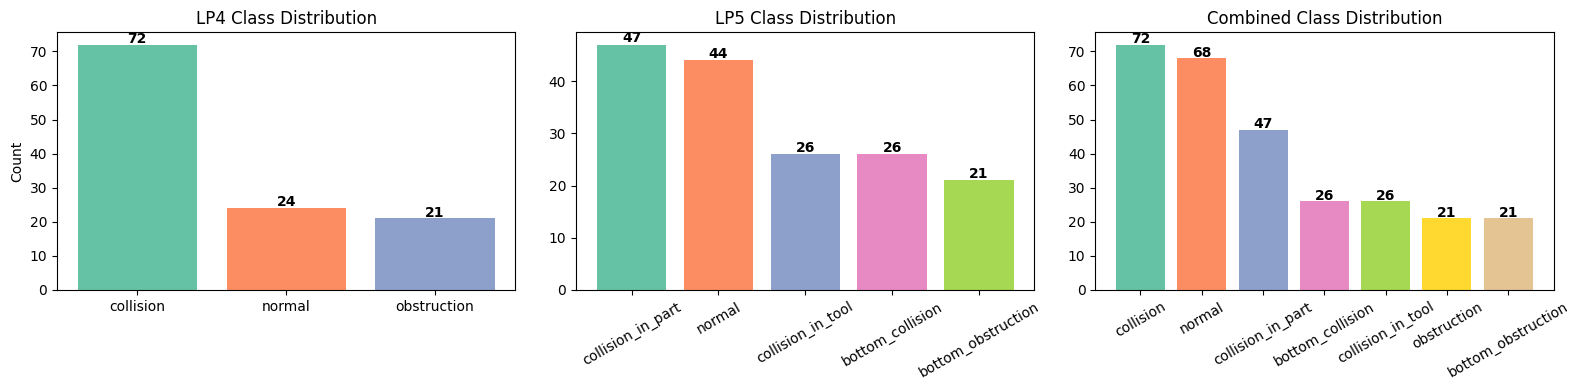


Class imbalance ratio (max/min):
  LP4: 72/21 = 3.4x
  LP5: 47/21 = 2.2x


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# LP4
lp4_counts = pd.Series(y_lp4).value_counts()
axes[0].bar(lp4_counts.index, lp4_counts.values, color=sns.color_palette("Set2", len(lp4_counts)))
axes[0].set_title("LP4 Class Distribution")
axes[0].set_ylabel("Count")
for i, (idx, v) in enumerate(lp4_counts.items()):
    axes[0].text(i, v + 0.5, str(v), ha="center", fontweight="bold")

# LP5
lp5_counts = pd.Series(y_lp5).value_counts()
axes[1].bar(lp5_counts.index, lp5_counts.values, color=sns.color_palette("Set2", len(lp5_counts)))
axes[1].set_title("LP5 Class Distribution")
for i, (idx, v) in enumerate(lp5_counts.items()):
    axes[1].text(i, v + 0.5, str(v), ha="center", fontweight="bold")
axes[1].tick_params(axis='x', rotation=30)

# Combined
all_counts = pd.Series(y_all).value_counts()
axes[2].bar(all_counts.index, all_counts.values, color=sns.color_palette("Set2", len(all_counts)))
axes[2].set_title("Combined Class Distribution")
axes[2].tick_params(axis='x', rotation=30)
for i, (idx, v) in enumerate(all_counts.items()):
    axes[2].text(i, v + 0.5, str(v), ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

print("\nClass imbalance ratio (max/min):")
print(f"  LP4: {lp4_counts.max()}/{lp4_counts.min()} = {lp4_counts.max()/lp4_counts.min():.1f}x")
print(f"  LP5: {lp5_counts.max()}/{lp5_counts.min()} = {lp5_counts.max()/lp5_counts.min():.1f}x")

### 3.2 Summary stats

Quick sanity check on the raw features - are there weird values, NaNs, etc?

In [9]:
print("Raw Feature Statistics (all 90 features)\n")
desc = df_all[col_names].describe().T
print(desc[["mean", "std", "min", "25%", "50%", "75%", "max"]].to_string(
    float_format=lambda x: f"{x:.1f}"))

print(f"\n\nGlobal range: [{df_all[col_names].min().min()}, {df_all[col_names].max().max()}]")
print(f"Any NaN values: {df_all[col_names].isna().any().any()}")

Raw Feature Statistics (all 90 features)

         mean   std     min   25%  50%  75%    max
Fx_t01    7.0  55.4  -130.0  -6.0 -2.0  8.0  353.0
Fy_t01   -1.7  44.3  -338.0  -6.0  0.0  3.0  168.0
Fz_t01  -61.0 439.9 -3617.0 -11.0  9.0 27.0  361.0
Tx_t01    4.6  92.7  -423.0 -15.0  3.0 11.0  476.0
Ty_t01   -1.2  86.9  -286.0 -21.0 -6.0  3.0  756.0
Tz_t01   -0.6  23.4  -122.0  -5.0  0.0  2.0  149.0
Fx_t02    6.5  50.9  -120.0  -6.0 -1.0 12.0  337.0
Fy_t02   -2.5  41.7  -360.0  -3.0  1.0  4.0  197.0
Fz_t02  -70.9 447.9 -3261.0  -4.0 10.0 27.0  131.0
Tx_t02    6.2  70.9  -215.0  -7.0  1.0  7.0  605.0
Ty_t02   -7.4  57.6  -243.0 -23.0 -5.0  7.0  195.0
Tz_t02   -0.3  16.0   -49.0  -4.0  0.0  2.0  135.0
Fx_t03    4.2  44.5  -132.0  -5.0 -1.0  8.0  331.0
Fy_t03   -3.8  44.4  -367.0  -6.0  0.0  4.0  276.0
Fz_t03  -81.6 425.8 -3281.0  -6.0  8.0 23.0  132.0
Tx_t03    3.3  69.3  -231.0  -9.0  1.0  6.0  620.0
Ty_t03    1.3  71.4  -238.0 -16.0 -5.0  7.0  476.0
Tz_t03   -0.8  15.5   -49.0  -4.0 -1.0  

### 3.3 Sensor traces

Let me plot some actual time series to see what different failure types look like. This is probably the most useful visualization for building intuition.

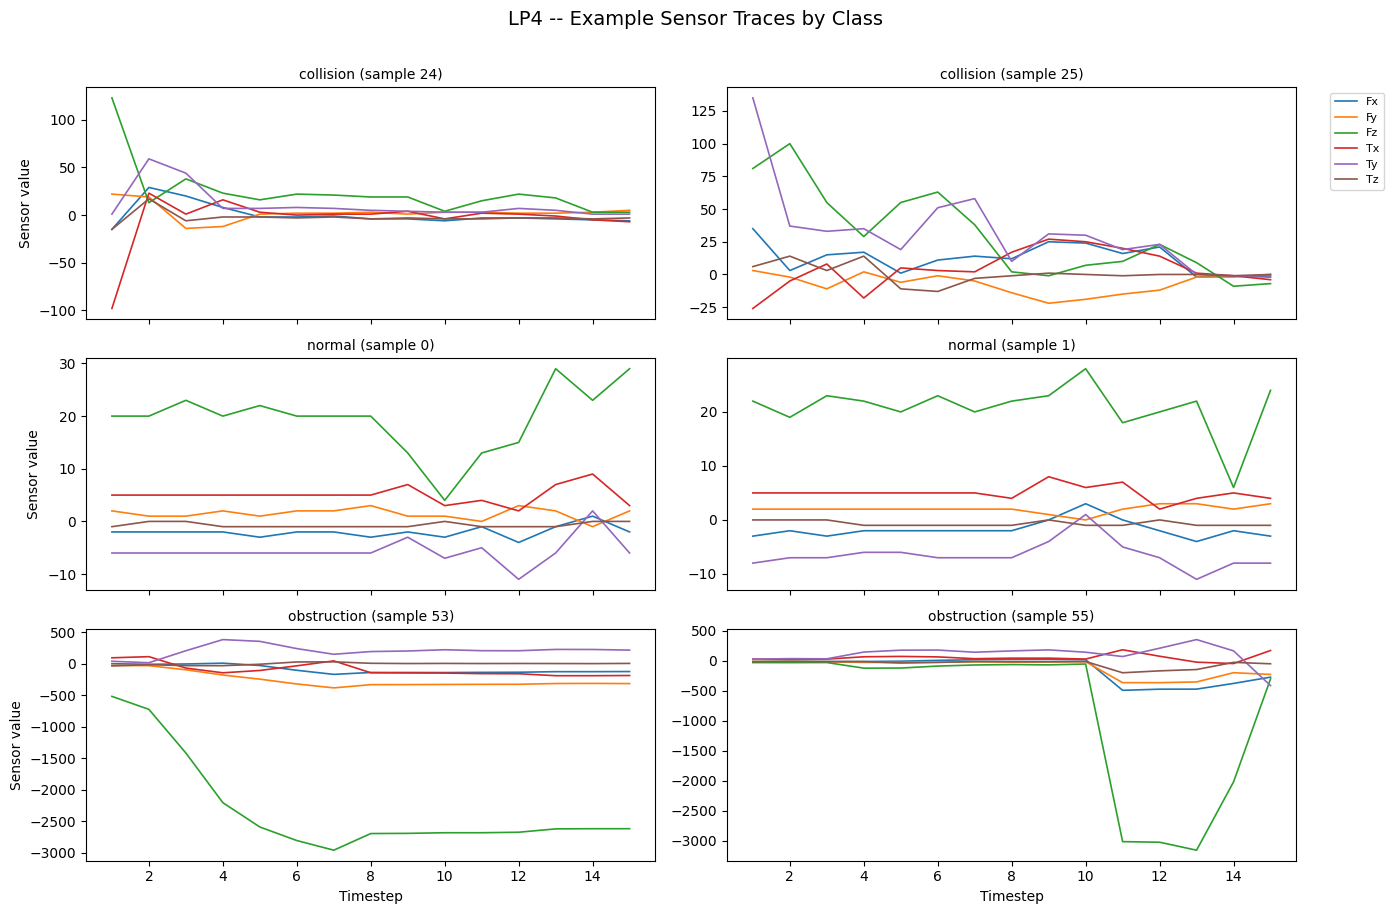

In [10]:
def plot_sample_traces(X_3d, y, title, n_per_class=2):
    """Plot example time series for each class."""
    classes = sorted(set(y))
    n_classes = len(classes)
    fig, axes = plt.subplots(n_classes, n_per_class, figsize=(14, 3 * n_classes), sharex=True)
    if n_classes == 1:
        axes = axes[np.newaxis, :]

    colors = sns.color_palette("tab10", N_CHANNELS)
    y_arr = np.array(y)

    for i, cls in enumerate(classes):
        idxs = np.where(y_arr == cls)[0]
        chosen = idxs[:n_per_class]
        for j, idx in enumerate(chosen):
            ax = axes[i, j]
            for ch in range(N_CHANNELS):
                ax.plot(range(1, N_TIMESTEPS + 1), X_3d[idx, :, ch],
                        label=CHANNELS[ch], color=colors[ch], linewidth=1.2)
            ax.set_title(f"{cls} (sample {idx})", fontsize=10)
            if j == 0:
                ax.set_ylabel("Sensor value")
            if i == n_classes - 1:
                ax.set_xlabel("Timestep")
            if i == 0 and j == n_per_class - 1:
                ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)

    fig.suptitle(title, fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

plot_sample_traces(X_lp4_3d, y_lp4, "LP4 -- Example Sensor Traces by Class")

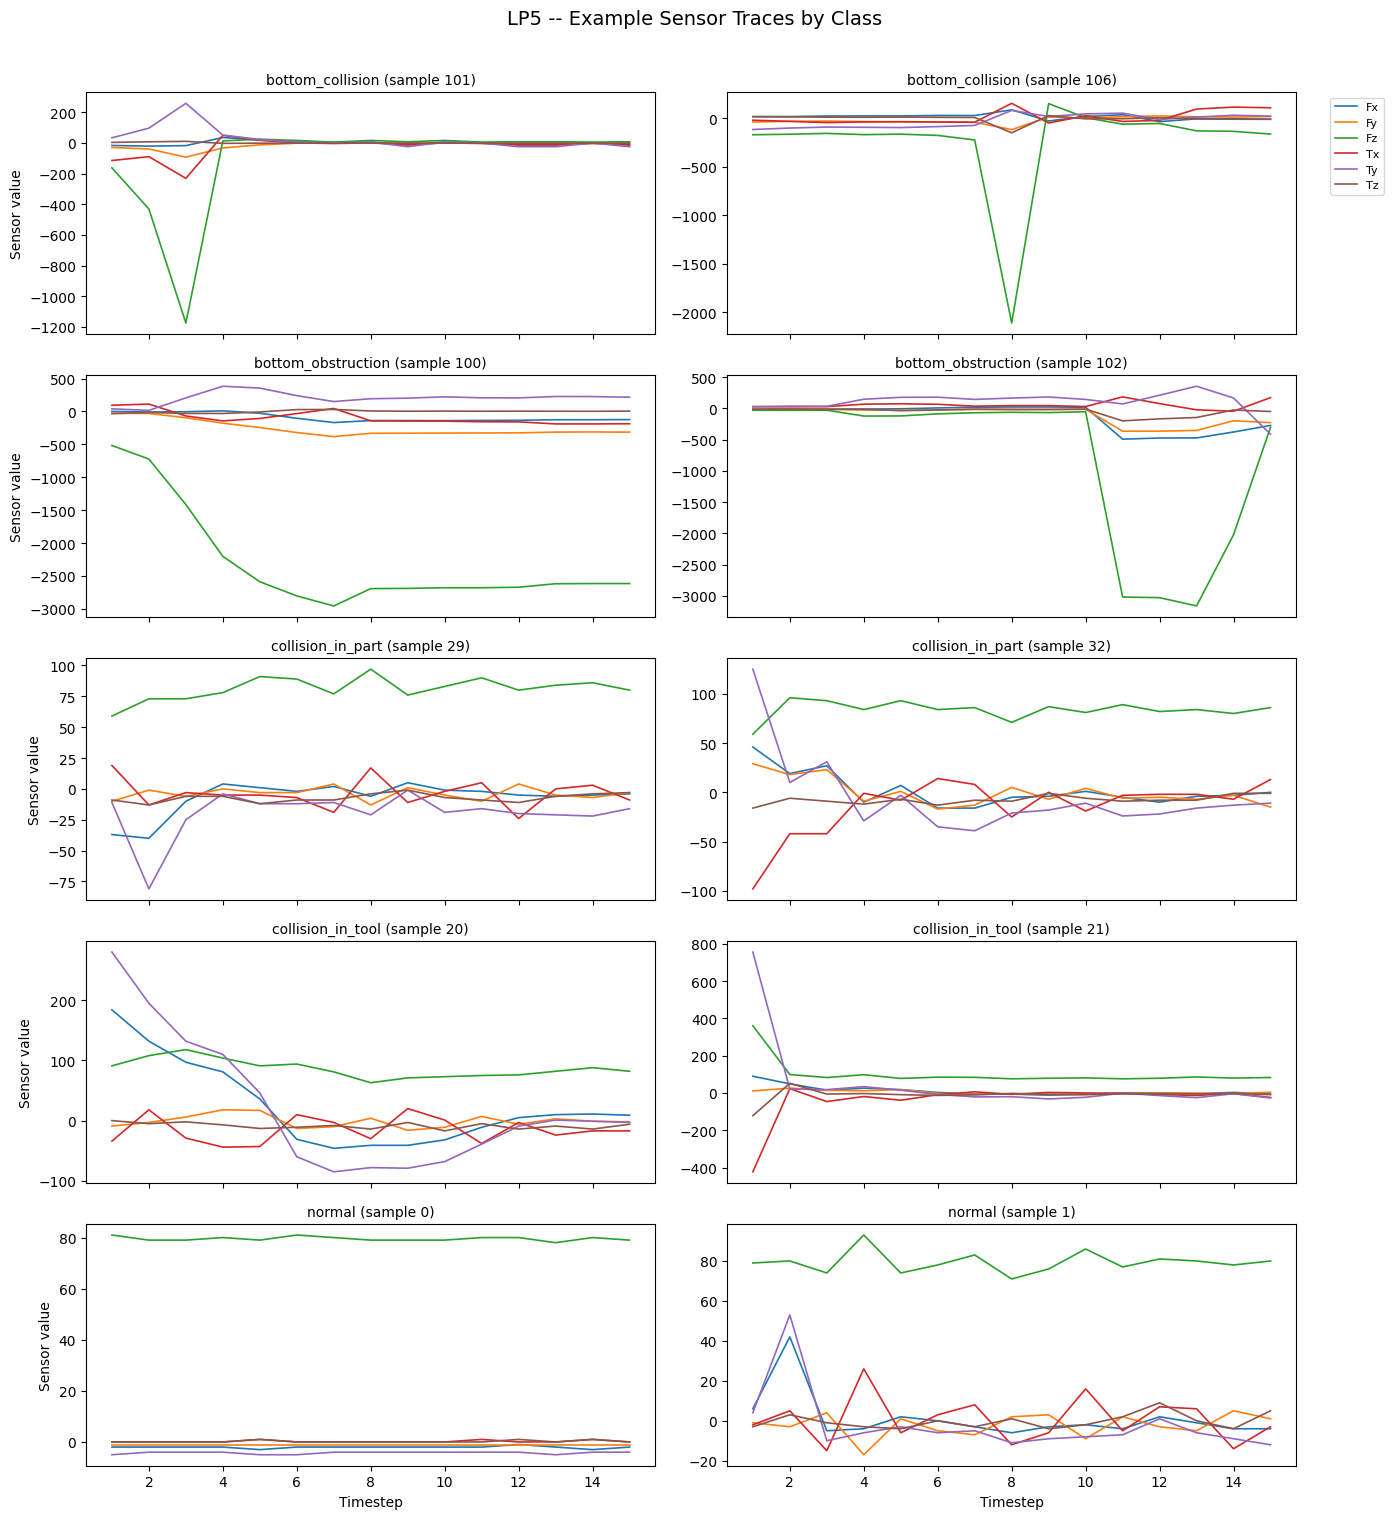

In [11]:
plot_sample_traces(X_lp5_3d, y_lp5, "LP5 -- Example Sensor Traces by Class")

### 3.4 Per-channel distributions

Box plots of the mean sensor value per channel, broken out by class. This should show which channels are most discriminative.

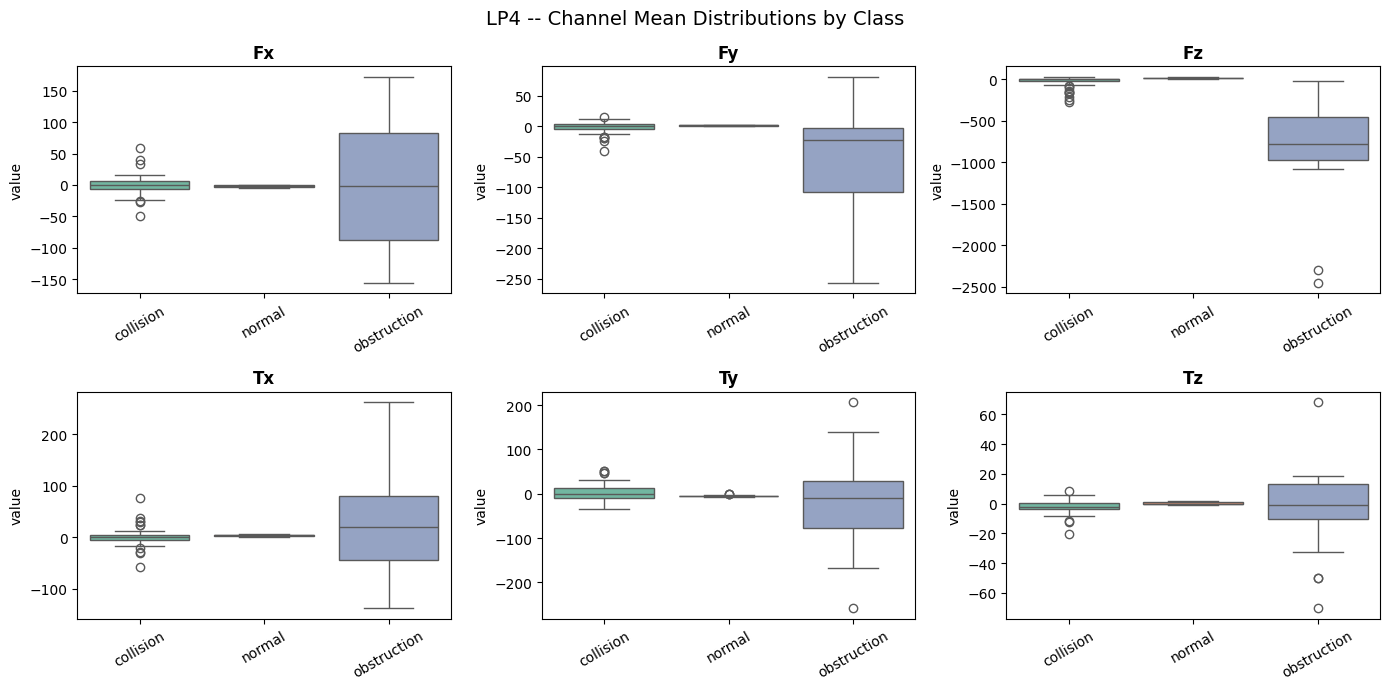

In [12]:
def plot_channel_distributions(X_3d, y, title):
    """Box plots of per-channel means, grouped by class."""
    y_arr = np.array(y)
    channel_means = X_3d.mean(axis=1)  # (n_samples, 6)

    fig, axes = plt.subplots(2, 3, figsize=(14, 7))
    for ch_idx, ax in enumerate(axes.flat):
        data, labels_list = [], []
        for cls in sorted(set(y)):
            mask = y_arr == cls
            data.extend(channel_means[mask, ch_idx].tolist())
            labels_list.extend([cls] * mask.sum())

        temp_df = pd.DataFrame({"value": data, "class": labels_list})
        sns.boxplot(data=temp_df, x="class", y="value", ax=ax, palette="Set2")
        ax.set_title(CHANNELS[ch_idx], fontweight="bold")
        ax.set_xlabel("")
        ax.tick_params(axis='x', rotation=30)

    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

plot_channel_distributions(X_lp4_3d, y_lp4, "LP4 -- Channel Mean Distributions by Class")

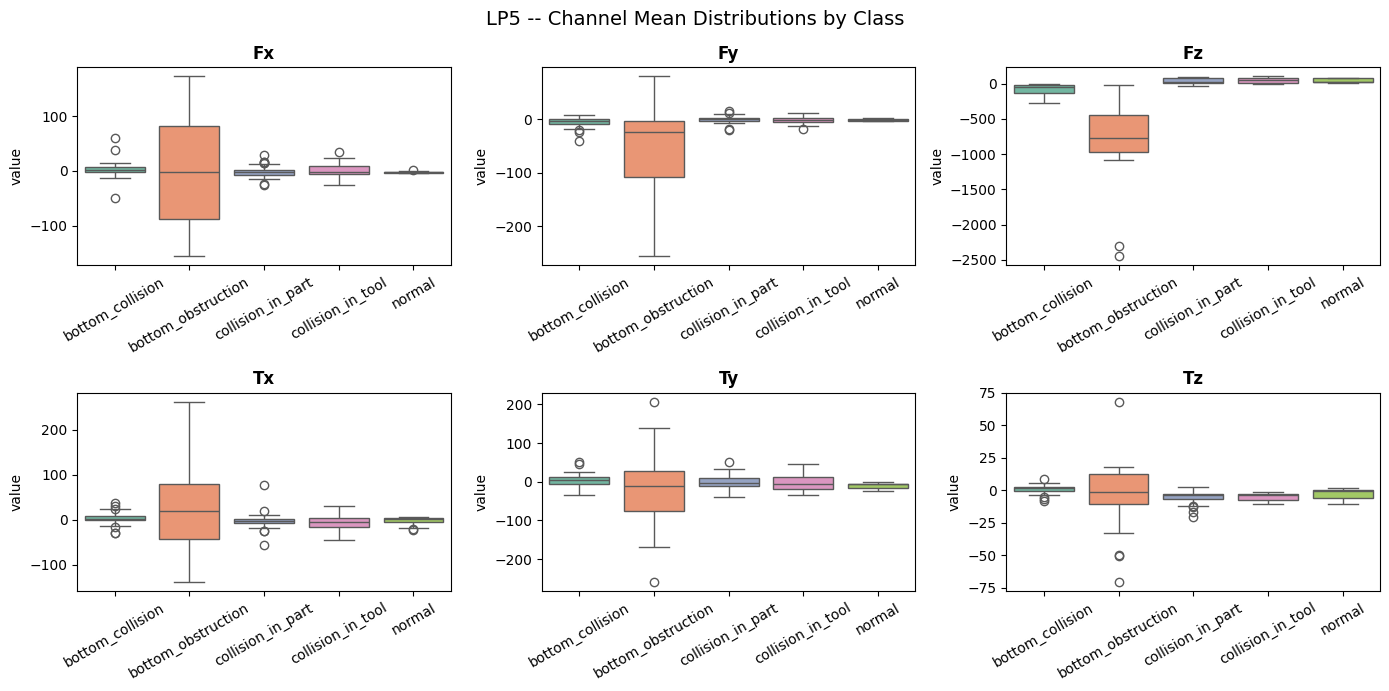

In [13]:
plot_channel_distributions(X_lp5_3d, y_lp5, "LP5 -- Channel Mean Distributions by Class")

### 3.5 Correlation between channels

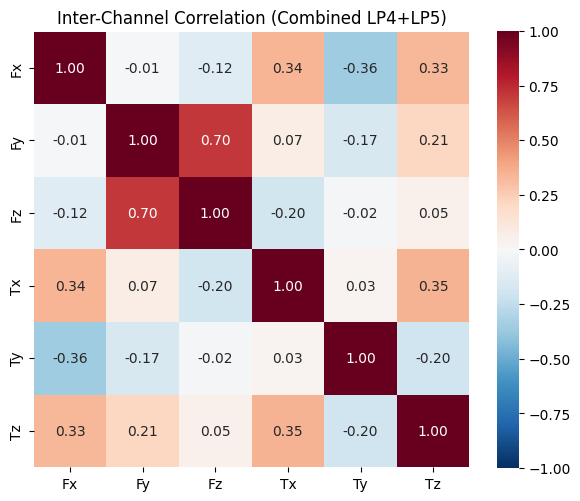

In [14]:
channel_means_all = X_all_3d.mean(axis=1)  # (281, 6)
corr_df = pd.DataFrame(channel_means_all, columns=CHANNELS).corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr_df, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, ax=ax, vmin=-1, vmax=1)
ax.set_title("Inter-Channel Correlation (Combined LP4+LP5)")
plt.tight_layout()
plt.show()

### 3.6 Outliers

Checking for extreme values with z-scores. Important to know before scaling.

Samples with any feature |z| > 3: 74 / 281 (26.3%)
Outlier class breakdown:
  bottom_collision: 6
  bottom_obstruction: 19
  collision      : 12
  collision_in_part: 12
  collision_in_tool: 6
  normal         : 0
  obstruction    : 19


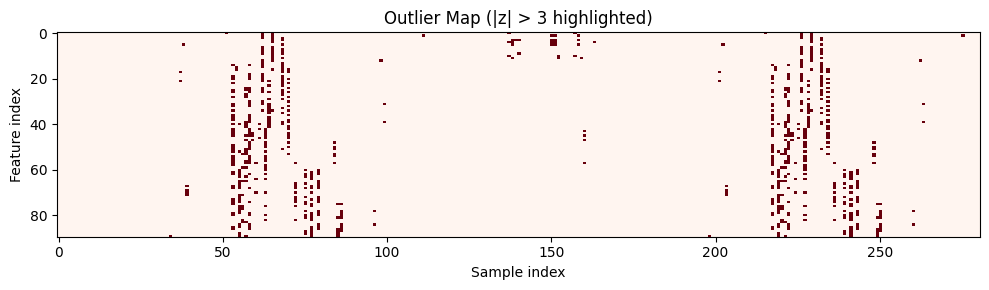

In [15]:
z_scores = np.abs(stats.zscore(X_all, axis=0))
outlier_mask = (z_scores > 3).any(axis=1)
n_outliers = outlier_mask.sum()

print(f"Samples with any feature |z| > 3: {n_outliers} / {len(X_all)} ({100*n_outliers/len(X_all):.1f}%)")
print(f"Outlier class breakdown:")
for cls in sorted(set(y_all)):
    cls_mask = (y_all == cls) & outlier_mask
    print(f"  {cls:15s}: {cls_mask.sum()}")

fig, ax = plt.subplots(figsize=(10, 3))
ax.imshow(z_scores.T > 3, aspect="auto", cmap="Reds", interpolation="nearest")
ax.set_xlabel("Sample index")
ax.set_ylabel("Feature index")
ax.set_title("Outlier Map (|z| > 3 highlighted)")
plt.tight_layout()
plt.show()

## 4. Feature Engineering

Instead of using the raw 90 features directly, I'm extracting more meaningful features from each channel's 15-step time series:

- **Statistical:** mean, std, max, min, skewness, kurtosis (6 per channel = 36)
- **Temporal:** mean absolute gradient (1 per channel = 6)  
- **Frequency:** FFT dominant magnitude, spectral energy, peak frequency (3 per channel = 18)

That gives 60 features total. The idea is that these capture the "shape" of each sensor trace better than raw timestep values.

In [16]:
def extract_features(X_3d):
    """
    Extract 60 engineered features from raw time-series data.

    Parameters:
        X_3d: ndarray, shape (n_samples, 15, 6)

    Returns:
        features: ndarray, shape (n_samples, 60)
        feature_names: list of 60 feature name strings
    """
    n_samples = X_3d.shape[0]
    all_features = []
    feature_names = []

    for ch_idx, ch_name in enumerate(CHANNELS):
        ch_data = X_3d[:, :, ch_idx]  # (n_samples, 15)

        # Statistical features (6 per channel)
        f_mean = ch_data.mean(axis=1)
        f_std  = ch_data.std(axis=1)
        f_max  = ch_data.max(axis=1)
        f_min  = ch_data.min(axis=1)
        f_skew = stats.skew(ch_data, axis=1)
        f_kurt = stats.kurtosis(ch_data, axis=1)

        # Handle NaN from constant series
        f_skew = np.nan_to_num(f_skew, nan=0.0)
        f_kurt = np.nan_to_num(f_kurt, nan=0.0)

        # Temporal features (1 per channel)
        gradients = np.diff(ch_data, axis=1)
        f_grad = np.mean(np.abs(gradients), axis=1)

        # Frequency-domain features (3 per channel)
        fft_vals = np.abs(fft(ch_data, axis=1))[:, 1:N_TIMESTEPS//2+1]  # skip DC
        f_fft_max    = fft_vals.max(axis=1)
        f_fft_energy = (fft_vals ** 2).sum(axis=1)
        f_fft_peak   = fft_vals.argmax(axis=1) + 1

        ch_features = np.column_stack([
            f_mean, f_std, f_max, f_min, f_skew, f_kurt,
            f_grad, f_fft_max, f_fft_energy, f_fft_peak
        ])
        all_features.append(ch_features)

        for fname in ["mean", "std", "max", "min", "skew", "kurt",
                       "grad", "fft_max", "fft_energy", "fft_peak"]:
            feature_names.append(f"{ch_name}_{fname}")

    return np.hstack(all_features), feature_names

# Extract features
feat_all, feat_names = extract_features(X_all_3d)
feat_lp4, _ = extract_features(X_lp4_3d)
feat_lp5, _ = extract_features(X_lp5_3d)

print(f"Engineered features shape: {feat_all.shape}")
print(f"Feature names ({len(feat_names)} total):")
print(f"  {feat_names[:10]}  ... (first 10)")

df_feat = pd.DataFrame(feat_all, columns=feat_names)
df_feat["label"] = y_all
df_feat["phase"] = phase_labels
df_feat.describe().T.head(10)

Engineered features shape: (281, 60)
Feature names (60 total):
  ['Fx_mean', 'Fx_std', 'Fx_max', 'Fx_min', 'Fx_skew', 'Fx_kurt', 'Fx_grad', 'Fx_fft_max', 'Fx_fft_energy', 'Fx_fft_peak']  ... (first 10)


,count,mean,std,min,25%,50%,75%,max
Fx_mean,281.0,0.191934,3.813110e+01,-155.933333,-4.466667,-1.733333,4.666667,1.724667e+02
Fx_std,281.0,26.365774,4.600244e+01,0.442217,2.578544,9.957688,25.614753,2.912467e+02
Fx_max,281.0,38.195730,7.906033e+01,-7.000000,1.000000,8.000000,35.000000,4.620000e+02
Fx_min,281.0,-44.156584,1.060941e+02,-883.000000,-33.000000,-11.000000,-4.000000,1.600000e+01
Fx_skew,281.0,-0.075257,1.171525e+00,-3.249976,-0.885455,-0.044201,0.666447,3.059151e+00
Fx_kurt,281.0,0.617799,2.155703e+00,-1.875625,-1.005335,-0.016489,1.719024,9.141966e+00
Fx_grad,281.0,10.908744,1.750534e+01,0.428571,2.071429,4.642857,12.142857,1.294286e+02
Fx_fft_max,281.0,205.472260,3.641412e+02,2.645751,18.562888,65.990238,188.254262,1.927964e+03
Fx_fft_energy,281.0,315432.793594,1.129181e+06,22.000000,748.000000,11155.000000,73813.000000,9.542773e+06
Fx_fft_peak,281.0,1.829181,1.434026e+00,1.000000,1.000000,1.000000,2.000000,7.000000e+00


## 5. Preprocessing & Dimensionality Reduction

### 5.1 Scaling

StandardScaler is the default choice for clustering. I'll also try MinMaxScaler later to see if it matters.

In [17]:
scaler_std = StandardScaler()
X_scaled = scaler_std.fit_transform(feat_all)
X_scaled = np.nan_to_num(X_scaled, nan=0.0)

scaler_mm = MinMaxScaler()
X_mm = scaler_mm.fit_transform(feat_all)
X_mm = np.nan_to_num(X_mm, nan=0.0)

print(f"StandardScaler -- mean: {X_scaled.mean():.4f}, std: {X_scaled.std():.4f}")
print(f"MinMaxScaler   -- range: [{X_mm.min():.4f}, {X_mm.max():.4f}]")

StandardScaler -- mean: -0.0000, std: 1.0000
MinMaxScaler   -- range: [0.0000, 1.0000]


### 5.2 PCA

60 features is still a lot for ~280 samples. PCA should help, and I want to see how many components I actually need.

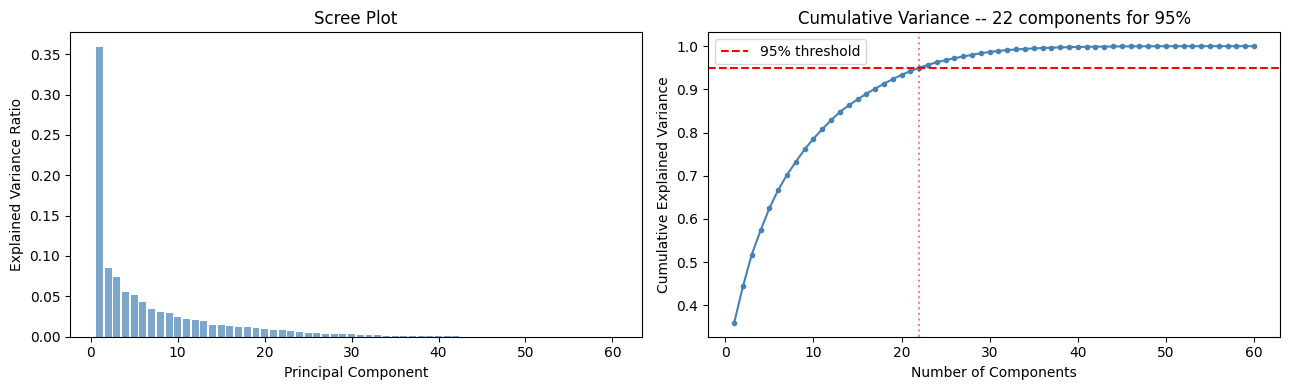


Components for 95% variance: 22
Top 5 PCs capture: 62.5% of variance


In [18]:
pca_full = PCA(random_state=SEED)
pca_full.fit(X_scaled)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_95 = np.argmax(cumvar >= 0.95) + 1

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(range(1, len(pca_full.explained_variance_ratio_) + 1),
            pca_full.explained_variance_ratio_, color="steelblue", alpha=0.7)
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Explained Variance Ratio")
axes[0].set_title("Scree Plot")

axes[1].plot(range(1, len(cumvar) + 1), cumvar, "o-", markersize=3, color="steelblue")
axes[1].axhline(0.95, color="red", linestyle="--", label="95% threshold")
axes[1].axvline(n_95, color="red", linestyle=":", alpha=0.5)
axes[1].set_xlabel("Number of Components")
axes[1].set_ylabel("Cumulative Explained Variance")
axes[1].set_title(f"Cumulative Variance -- {n_95} components for 95%")
axes[1].legend()

plt.tight_layout()
plt.show()
print(f"\nComponents for 95% variance: {n_95}")
print(f"Top 5 PCs capture: {cumvar[4]*100:.1f}% of variance")

In [19]:
pca = PCA(n_components=n_95, random_state=SEED)
X_pca = pca.fit_transform(X_scaled)
print(f"PCA-reduced shape: {X_pca.shape}")

PCA-reduced shape: (281, 22)


### 5.3 PCA scatter plot

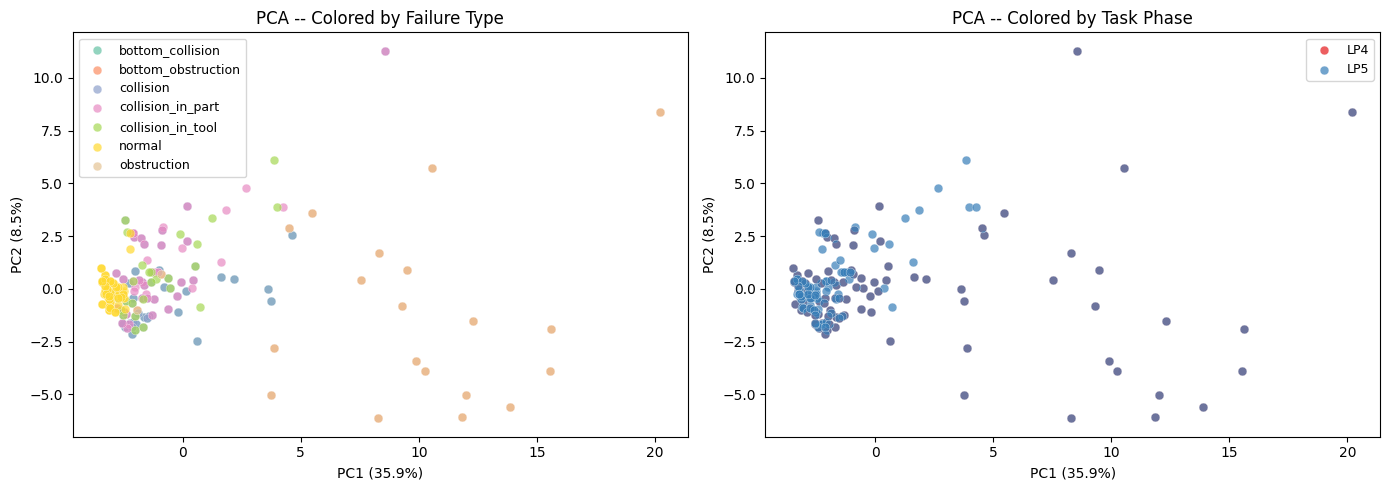

In [20]:
def scatter_2d(X_2d, labels, title, ax=None, palette="Set2"):
    """Scatter plot colored by labels."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 5))
    unique = sorted(set(labels))
    colors = sns.color_palette(palette, len(unique))
    for i, cls in enumerate(unique):
        mask = np.array(labels) == cls
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1], c=[colors[i]], label=cls,
                   alpha=0.7, edgecolors="w", linewidth=0.3, s=40)
    ax.legend(fontsize=9)
    ax.set_title(title)
    return ax

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

scatter_2d(X_pca[:, :2], y_all, "PCA -- Colored by Failure Type", ax=axes[0])
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")

scatter_2d(X_pca[:, :2], phase_labels, "PCA -- Colored by Task Phase", ax=axes[1], palette="Set1")
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")

plt.tight_layout()
plt.show()

### 5.4 t-SNE

PCA is linear so it might miss nonlinear structure. t-SNE should give a better picture of the actual clusters.

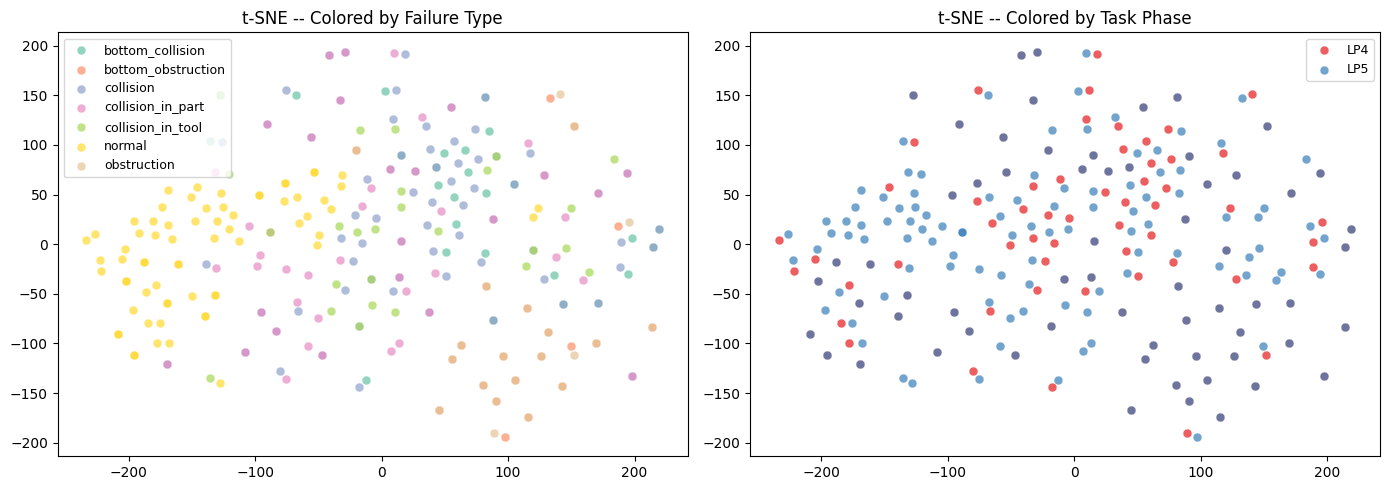

Key observation: Check whether the dominant structure in the 2D projection
separates by failure type or by task phase (LP4 vs LP5).


In [21]:
# n_iter was renamed to max_iter in sklearn 1.8
try:
    tsne = TSNE(n_components=2, perplexity=30, random_state=SEED, max_iter=1000)
    X_tsne = tsne.fit_transform(X_pca)
except TypeError:
    tsne = TSNE(n_components=2, perplexity=30, random_state=SEED, n_iter=1000)
    X_tsne = tsne.fit_transform(X_pca)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
scatter_2d(X_tsne, y_all, "t-SNE -- Colored by Failure Type", ax=axes[0])
scatter_2d(X_tsne, phase_labels, "t-SNE -- Colored by Task Phase", ax=axes[1], palette="Set1")
plt.tight_layout()
plt.show()

print("Key observation: Check whether the dominant structure in the 2D projection")
print("separates by failure type or by task phase (LP4 vs LP5).")

## 6. K-Means

### 6.1 Choosing k

Running the standard elbow + silhouette analysis. I'm also plotting ARI/NMI against k to see where the external metrics peak.

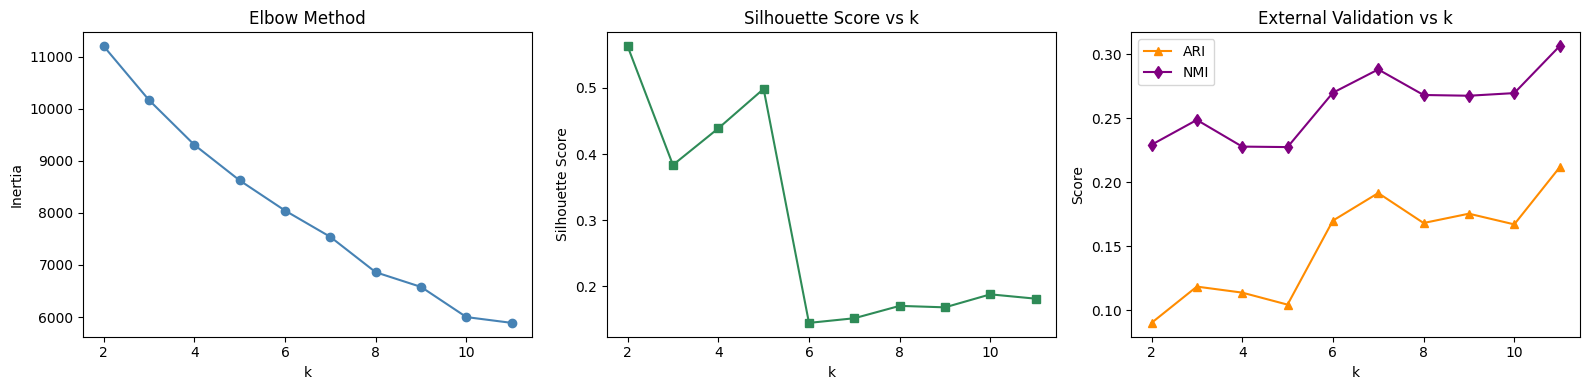


Best k by silhouette: 2 (score = 0.5631)


In [22]:
k_range = range(2, 12)
inertias, silhouettes, aris, nmis = [], [], [], []

for k in k_range:
    km = KMeans(n_clusters=k, n_init=20, random_state=SEED)
    pred = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_pca, pred))
    aris.append(adjusted_rand_score(y_all, pred))
    nmis.append(normalized_mutual_info_score(y_all, pred))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(k_range, inertias, "o-", color="steelblue")
axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia"); axes[0].set_title("Elbow Method")

axes[1].plot(k_range, silhouettes, "s-", color="seagreen")
axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette Score"); axes[1].set_title("Silhouette Score vs k")

axes[2].plot(k_range, aris, "^-", color="darkorange", label="ARI")
axes[2].plot(k_range, nmis, "d-", color="purple", label="NMI")
axes[2].set_xlabel("k"); axes[2].set_ylabel("Score"); axes[2].set_title("External Validation vs k")
axes[2].legend()

plt.tight_layout()
plt.show()

best_k_sil = list(k_range)[np.argmax(silhouettes)]
print(f"\nBest k by silhouette: {best_k_sil} (score = {max(silhouettes):.4f})")

### 6.2 K-Means results

Trying two settings: k = number of true classes (to see how well K-Means recovers the ground truth) and k = silhouette-optimal (what the algorithm "wants" to do).

In [23]:
n_true_classes = len(set(y_all))

def evaluate_clustering(pred, y_true, X_embed, method_name):
    """Print all the metrics for a given clustering result."""
    sil = silhouette_score(X_embed, pred) if len(set(pred)) >= 2 else -1
    db  = davies_bouldin_score(X_embed, pred) if len(set(pred)) >= 2 else -1
    ch  = calinski_harabasz_score(X_embed, pred) if len(set(pred)) >= 2 else -1
    ari = adjusted_rand_score(y_true, pred)
    nmi = normalized_mutual_info_score(y_true, pred)

    total_correct = 0
    for cl in np.unique(pred):
        total_correct += Counter(y_true[pred == cl]).most_common(1)[0][1]
    purity = total_correct / len(y_true)

    print(f"\n{method_name}")
    print(f"  Silhouette Score:       {sil:.4f}")
    print(f"  Davies-Bouldin Index:   {db:.4f}  (lower is better)")
    print(f"  Calinski-Harabasz:      {ch:.1f}   (higher is better)")
    print(f"  Adjusted Rand Index:    {ari:.4f}")
    print(f"  Normalized Mutual Info: {nmi:.4f}")
    print(f"  Cluster Purity:         {purity:.4f}")

    return {"sil": sil, "db": db, "ch": ch, "ari": ari, "nmi": nmi, "purity": purity, "pred": pred}

results = {}

km_true = KMeans(n_clusters=n_true_classes, n_init=20, random_state=SEED)
pred_km_true = km_true.fit_predict(X_pca)
results["K-Means (k=true)"] = evaluate_clustering(
    pred_km_true, y_all, X_pca, f"K-Means (k={n_true_classes}, true classes)")

km_best = KMeans(n_clusters=best_k_sil, n_init=20, random_state=SEED)
pred_km_best = km_best.fit_predict(X_pca)
results[f"K-Means (k={best_k_sil})"] = evaluate_clustering(
    pred_km_best, y_all, X_pca, f"K-Means (k={best_k_sil}, silhouette-optimal)")


K-Means (k=7, true classes)
  Silhouette Score:       0.1520
  Davies-Bouldin Index:   1.6665  (lower is better)
  Calinski-Harabasz:      51.4   (higher is better)
  Adjusted Rand Index:    0.1916
  Normalized Mutual Info: 0.2881
  Cluster Purity:         0.4591

K-Means (k=2, silhouette-optimal)
  Silhouette Score:       0.5631
  Davies-Bouldin Index:   1.3002  (lower is better)
  Calinski-Harabasz:      120.0   (higher is better)
  Adjusted Rand Index:    0.0901
  Normalized Mutual Info: 0.2293
  Cluster Purity:         0.3096


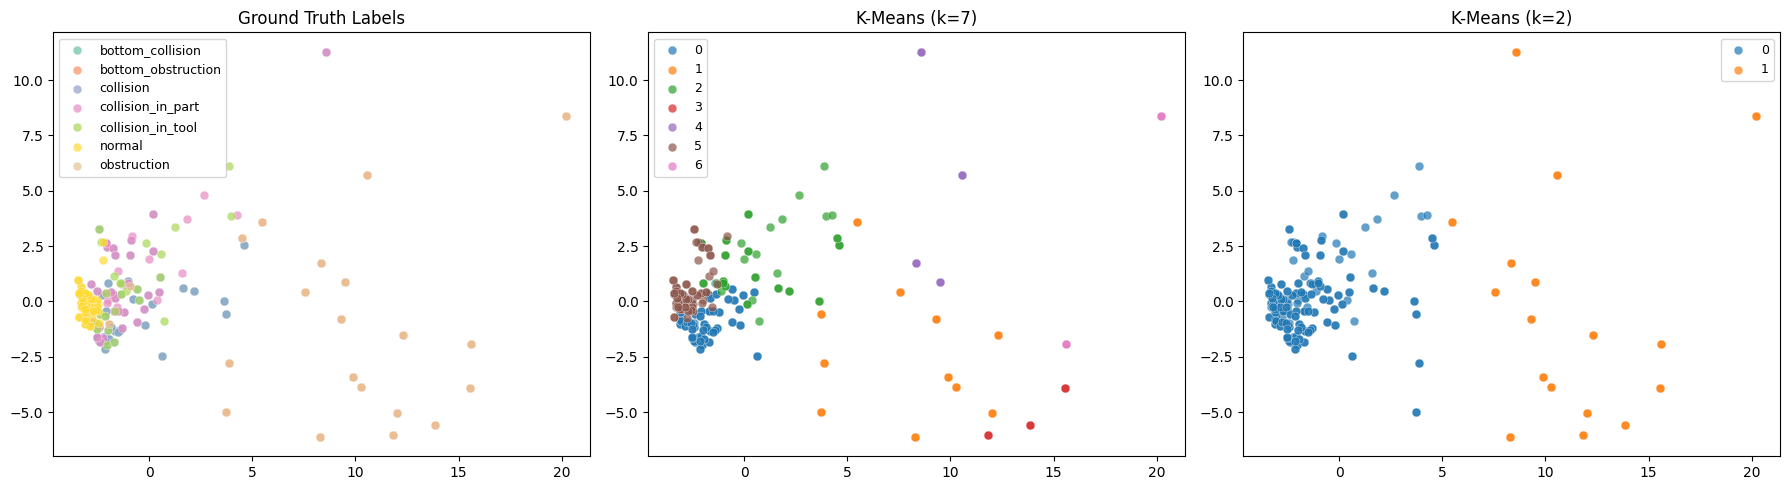

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

scatter_2d(X_pca[:, :2], y_all, "Ground Truth Labels", ax=axes[0])
scatter_2d(X_pca[:, :2], pred_km_true.astype(str),
           f"K-Means (k={n_true_classes})", ax=axes[1], palette="tab10")
scatter_2d(X_pca[:, :2], pred_km_best.astype(str),
           f"K-Means (k={best_k_sil})", ax=axes[2], palette="tab10")

plt.tight_layout()
plt.show()

## 7. Gaussian Mixture Models

GMMs are more flexible than K-Means since they give soft assignments and can model elliptical clusters. I want to compare different covariance types and use BIC to pick the best model.

### 7.1 BIC/AIC model selection

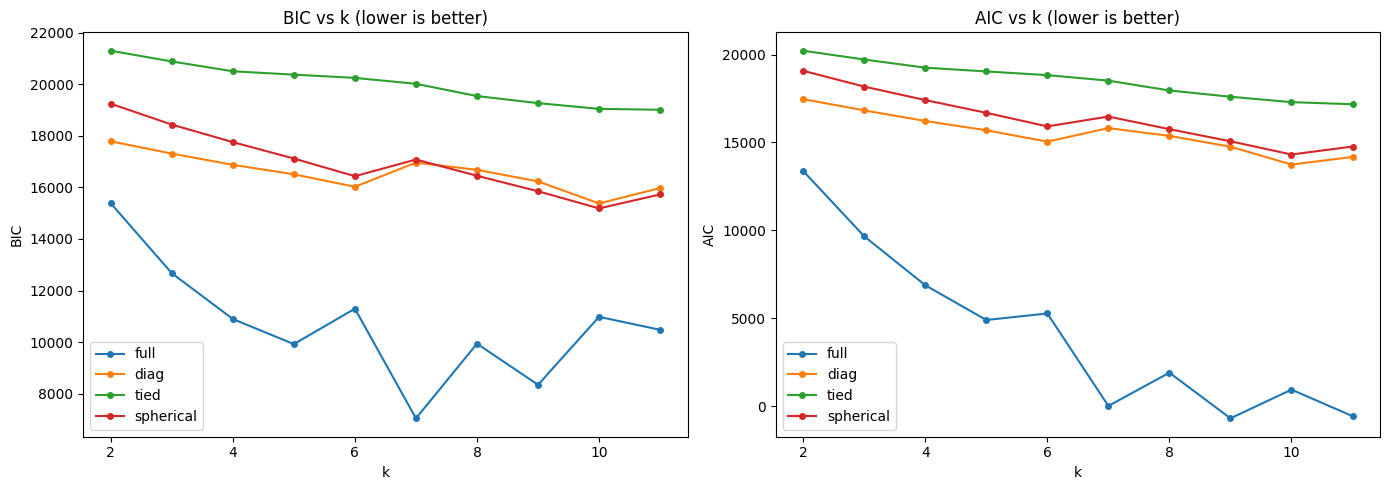


Best by BIC: k=7, covariance_type='full' (BIC=7039.5)


In [25]:
k_range_gmm = range(2, 12)
cov_types = ["full", "diag", "tied", "spherical"]
bic_results, aic_results = {}, {}

for ct in cov_types:
    bics, aics = [], []
    for k in k_range_gmm:
        gmm = GaussianMixture(n_components=k, covariance_type=ct,
                               n_init=5, random_state=SEED, max_iter=300)
        gmm.fit(X_pca)
        bics.append(gmm.bic(X_pca))
        aics.append(gmm.aic(X_pca))
    bic_results[ct] = bics
    aic_results[ct] = aics

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ct in cov_types:
    axes[0].plot(k_range_gmm, bic_results[ct], "o-", label=ct, markersize=4)
    axes[1].plot(k_range_gmm, aic_results[ct], "o-", label=ct, markersize=4)

axes[0].set_title("BIC vs k (lower is better)")
axes[0].set_xlabel("k"); axes[0].set_ylabel("BIC"); axes[0].legend()
axes[1].set_title("AIC vs k (lower is better)")
axes[1].set_xlabel("k"); axes[1].set_ylabel("AIC"); axes[1].legend()

plt.tight_layout()
plt.show()

best_bic = np.inf
best_k_gmm, best_ct = None, None
for ct in cov_types:
    for i, k in enumerate(k_range_gmm):
        if bic_results[ct][i] < best_bic:
            best_bic = bic_results[ct][i]
            best_k_gmm, best_ct = k, ct

print(f"\nBest by BIC: k={best_k_gmm}, covariance_type='{best_ct}' (BIC={best_bic:.1f})")

### 7.2 GMM results

In [26]:
# BIC-optimal
gmm_best = GaussianMixture(n_components=best_k_gmm, covariance_type=best_ct,
                            n_init=5, random_state=SEED, max_iter=300)
pred_gmm_best = gmm_best.fit_predict(X_pca)
results[f"GMM ({best_ct}, k={best_k_gmm})"] = evaluate_clustering(
    pred_gmm_best, y_all, X_pca, f"GMM (k={best_k_gmm}, {best_ct}, BIC-optimal)")

# Also try at k = true classes with full and diag covariance
for ct in ["full", "diag"]:
    gmm = GaussianMixture(n_components=n_true_classes, covariance_type=ct,
                           n_init=5, random_state=SEED, max_iter=300)
    pred = gmm.fit_predict(X_pca)
    results[f"GMM ({ct}, k={n_true_classes})"] = evaluate_clustering(
        pred, y_all, X_pca, f"GMM (k={n_true_classes}, {ct})")


GMM (k=7, full, BIC-optimal)
  Silhouette Score:       0.1180
  Davies-Bouldin Index:   2.0808  (lower is better)
  Calinski-Harabasz:      41.2   (higher is better)
  Adjusted Rand Index:    0.3087
  Normalized Mutual Info: 0.3563
  Cluster Purity:         0.5160

GMM (k=7, full)
  Silhouette Score:       0.1180
  Davies-Bouldin Index:   2.0808  (lower is better)
  Calinski-Harabasz:      41.2   (higher is better)
  Adjusted Rand Index:    0.3087
  Normalized Mutual Info: 0.3563
  Cluster Purity:         0.5160

GMM (k=7, diag)
  Silhouette Score:       0.1081
  Davies-Bouldin Index:   1.4628  (lower is better)
  Calinski-Harabasz:      41.7   (higher is better)
  Adjusted Rand Index:    0.1532
  Normalized Mutual Info: 0.2553
  Cluster Purity:         0.4413


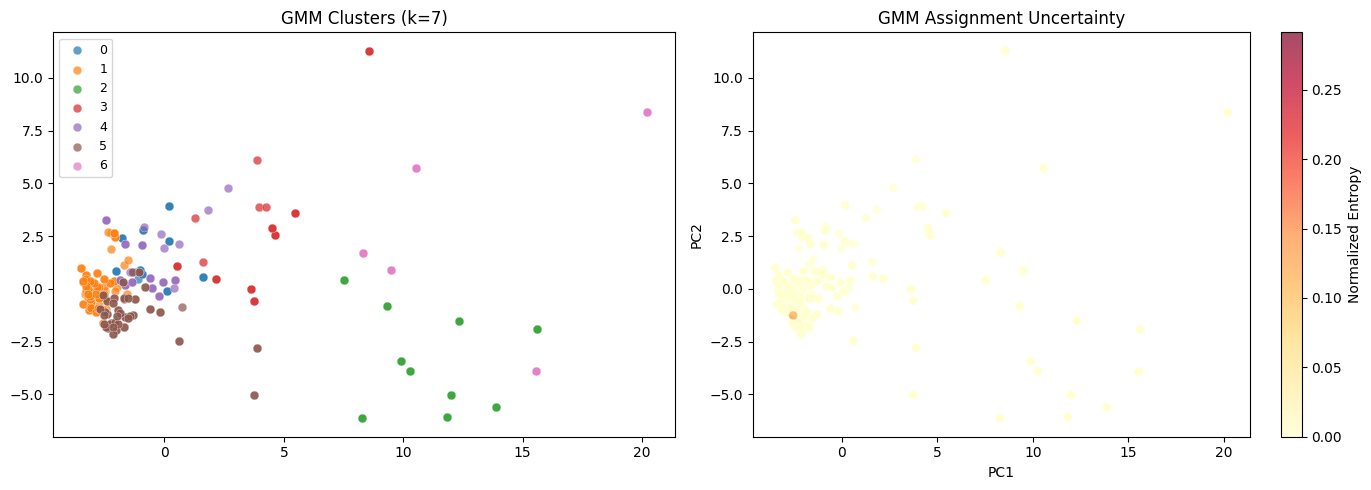

Mean assignment entropy: 0.003
Samples with entropy > 0.5 (highly uncertain): 0


In [27]:
# Visualize the soft assignments - entropy shows how uncertain the GMM is
gmm_vis = GaussianMixture(n_components=best_k_gmm, covariance_type=best_ct,
                           n_init=5, random_state=SEED, max_iter=300)
gmm_vis.fit(X_pca)
probs = gmm_vis.predict_proba(X_pca)

# High entropy = uncertain, low = confident
entropy = -np.sum(probs * np.log(probs + 1e-10), axis=1)
entropy_norm = entropy / np.log(best_k_gmm)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

scatter_2d(X_pca[:, :2], gmm_vis.predict(X_pca).astype(str),
           f"GMM Clusters (k={best_k_gmm})", ax=axes[0], palette="tab10")

sc = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=entropy_norm, cmap="YlOrRd",
                     alpha=0.7, edgecolors="w", linewidth=0.3, s=40)
plt.colorbar(sc, ax=axes[1], label="Normalized Entropy")
axes[1].set_title("GMM Assignment Uncertainty")
axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2")

plt.tight_layout()
plt.show()

print(f"Mean assignment entropy: {entropy_norm.mean():.3f}")
print(f"Samples with entropy > 0.5 (highly uncertain): {(entropy_norm > 0.5).sum()}")

## 8. Autoencoder + Latent-Space Clustering

The idea here: use a bottleneck autoencoder to learn a compressed representation, then cluster in that latent space. Maybe the nonlinear encoding captures something PCA misses.

Architecture: `60 -> 128 -> 32 -> 16 -> 32 -> 128 -> 60` (symmetric, 16-dim bottleneck)

I'm using sklearn's MLPRegressor as a hacky autoencoder - train it to reconstruct its own input, then grab the hidden activations at the bottleneck layer.

Autoencoder converged in 173 iterations
Final loss: 0.013436


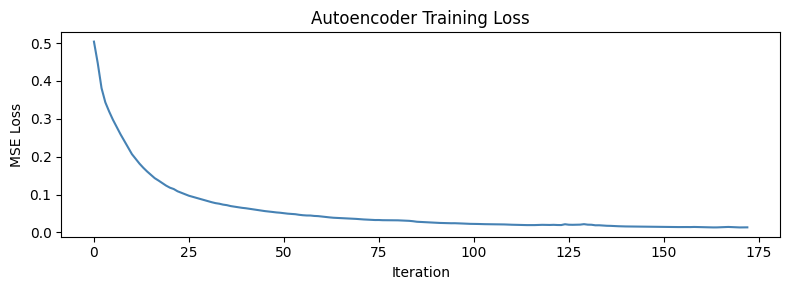

In [28]:
ae = MLPRegressor(
    hidden_layer_sizes=(128, 32, 16, 32, 128),
    activation="relu",
    solver="adam",
    max_iter=1000,
    random_state=SEED,
    early_stopping=True,
    validation_fraction=0.15,
    tol=1e-5,
    learning_rate_init=0.001,
    batch_size=32,
)

ae.fit(X_scaled, X_scaled)

print(f"Autoencoder converged in {ae.n_iter_} iterations")
print(f"Final loss: {ae.loss_:.6f}")

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(ae.loss_curve_, color="steelblue")
ax.set_xlabel("Iteration"); ax.set_ylabel("MSE Loss")
ax.set_title("Autoencoder Training Loss")
plt.tight_layout()
plt.show()

### 8.1 Extracting the latent vectors

To get the 16-dim representation, I need to do a manual forward pass through just the encoder half (first 3 weight matrices).

In [29]:
def get_latent_representation(ae_model, X):
    """
    Extract the bottleneck (latent) activation from a trained MLPRegressor.

    For architecture (128, 32, 16, 32, 128):
      Layer 0: input -> 128
      Layer 1: 128 -> 32
      Layer 2: 32 -> 16   <-- latent layer
    """
    hidden = X.copy()
    for i in range(3):  # 3 encoder layers
        hidden = hidden @ ae_model.coefs_[i] + ae_model.intercepts_[i]
        hidden = np.maximum(hidden, 0)  # ReLU
    return hidden

X_latent = get_latent_representation(ae, X_scaled)
print(f"Latent representation shape: {X_latent.shape}")

# Sanity check - how good is the reconstruction?
X_recon = ae.predict(X_scaled)
recon_error = np.mean((X_scaled - X_recon) ** 2, axis=1)
print(f"Mean reconstruction MSE: {recon_error.mean():.6f}")
print(f"Max  reconstruction MSE: {recon_error.max():.6f}")

Latent representation shape: (281, 16)
Mean reconstruction MSE: 0.029597
Max  reconstruction MSE: 0.253885


### 8.2 Latent space visualization

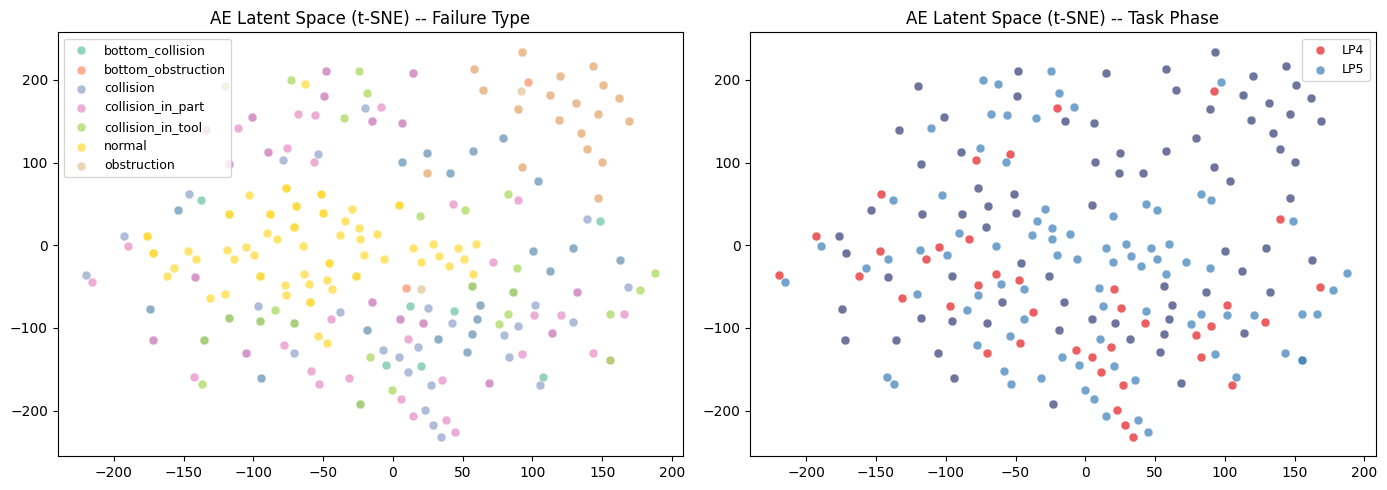

In [30]:
try:
    tsne_latent = TSNE(n_components=2, perplexity=30, random_state=SEED, max_iter=1000)
except TypeError:
    tsne_latent = TSNE(n_components=2, perplexity=30, random_state=SEED, n_iter=1000)
X_latent_2d = tsne_latent.fit_transform(X_latent)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
scatter_2d(X_latent_2d, y_all, "AE Latent Space (t-SNE) -- Failure Type", ax=axes[0])
scatter_2d(X_latent_2d, phase_labels, "AE Latent Space (t-SNE) -- Task Phase", ax=axes[1], palette="Set1")
plt.tight_layout()
plt.show()

### 8.3 Clustering in latent space

In [31]:
for k in [n_true_classes, best_k_sil]:
    km_latent = KMeans(n_clusters=k, n_init=20, random_state=SEED)
    pred_ae = km_latent.fit_predict(X_latent)
    results[f"AE + K-Means (k={k})"] = evaluate_clustering(
        pred_ae, y_all, X_latent, f"AE + K-Means (k={k}, latent 16D)")


AE + K-Means (k=7, latent 16D)
  Silhouette Score:       0.2976
  Davies-Bouldin Index:   1.3441  (lower is better)
  Calinski-Harabasz:      94.4   (higher is better)
  Adjusted Rand Index:    0.1042
  Normalized Mutual Info: 0.2276
  Cluster Purity:         0.3488

AE + K-Means (k=2, latent 16D)
  Silhouette Score:       0.6381
  Davies-Bouldin Index:   0.9420  (lower is better)
  Calinski-Harabasz:      235.6   (higher is better)
  Adjusted Rand Index:    0.0999
  Normalized Mutual Info: 0.2406
  Cluster Purity:         0.3132


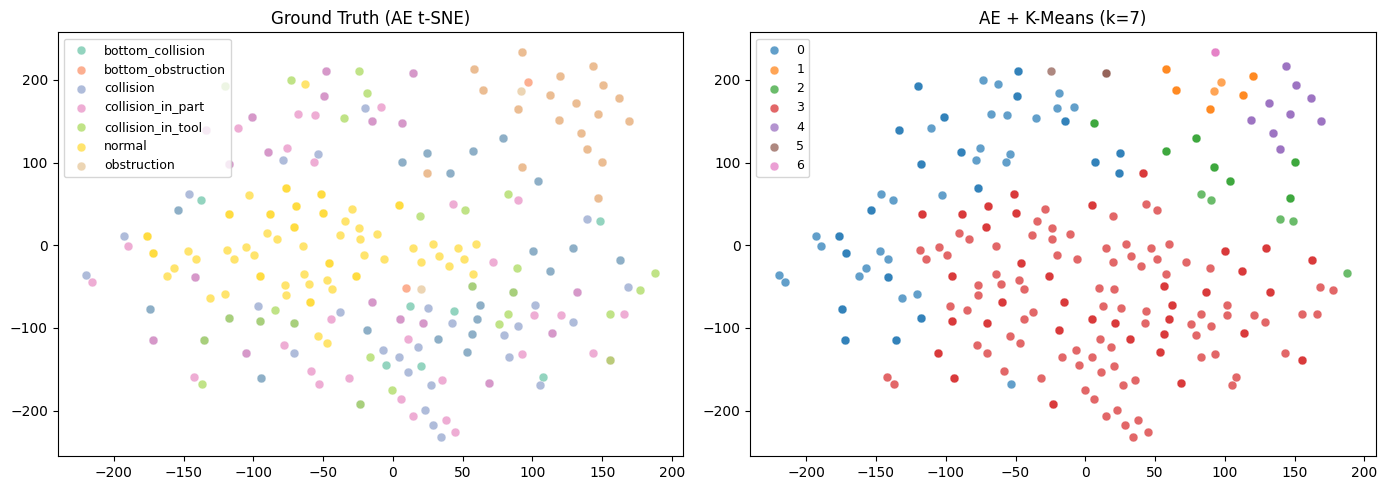

In [32]:
km_ae_vis = KMeans(n_clusters=n_true_classes, n_init=20, random_state=SEED)
pred_ae_vis = km_ae_vis.fit_predict(X_latent)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
scatter_2d(X_latent_2d, y_all, "Ground Truth (AE t-SNE)", ax=axes[0])
scatter_2d(X_latent_2d, pred_ae_vis.astype(str),
           f"AE + K-Means (k={n_true_classes})", ax=axes[1], palette="tab10")
plt.tight_layout()
plt.show()

## 9. Comparison

### 9.1 Results table

In [33]:
comparison_rows = []
for name, r in results.items():
    comparison_rows.append({
        "Method": name,
        "Silhouette": r["sil"],
        "Davies-Bouldin": r["db"],
        "ARI": r["ari"],
        "NMI": r["nmi"],
        "Purity": r["purity"],
    })

comp_df = pd.DataFrame(comparison_rows)
comp_df = comp_df.sort_values("ARI", ascending=False).reset_index(drop=True)

print("=" * 85)
print("METHOD COMPARISON -- All Clustering Results (Combined LP4+LP5)")
print("=" * 85)
print(comp_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

METHOD COMPARISON -- All Clustering Results (Combined LP4+LP5)
            Method  Silhouette  Davies-Bouldin    ARI    NMI  Purity
   GMM (full, k=7)      0.1180          2.0808 0.3087 0.3563  0.5160
  K-Means (k=true)      0.1520          1.6665 0.1916 0.2881  0.4591
   GMM (diag, k=7)      0.1081          1.4628 0.1532 0.2553  0.4413
AE + K-Means (k=7)      0.2976          1.3441 0.1042 0.2276  0.3488
AE + K-Means (k=2)      0.6381          0.9420 0.0999 0.2406  0.3132
     K-Means (k=2)      0.5631          1.3002 0.0901 0.2293  0.3096


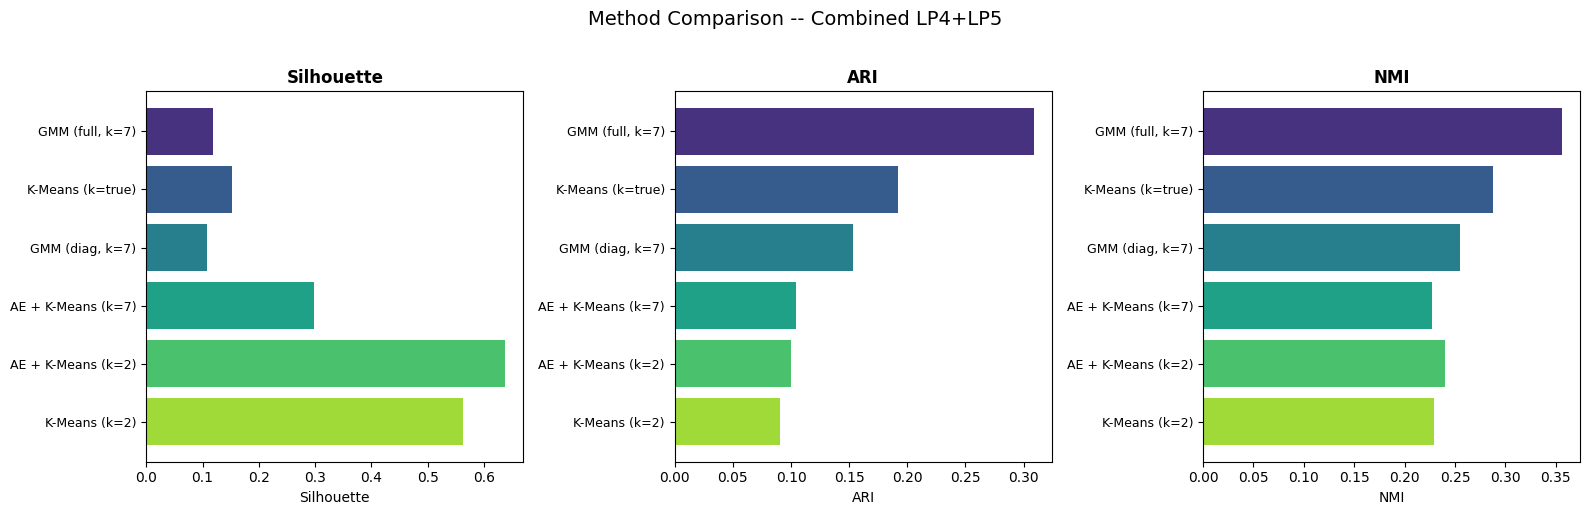

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
methods = comp_df["Method"].values

for i, metric in enumerate(["Silhouette", "ARI", "NMI"]):
    ax = axes[i]
    vals = comp_df[metric].values
    colors = sns.color_palette("viridis", len(methods))
    ax.barh(range(len(methods)), vals, color=colors)
    ax.set_yticks(range(len(methods)))
    ax.set_yticklabels(methods, fontsize=9)
    ax.set_xlabel(metric)
    ax.set_title(metric, fontweight="bold")
    ax.invert_yaxis()

plt.suptitle("Method Comparison -- Combined LP4+LP5", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 9.2 Robustness check (5-fold repeated evaluation)

In [35]:
print("Repeated Evaluation (5-fold random sub-sampling)\n")

splitter = ShuffleSplit(n_splits=5, test_size=0.2, random_state=SEED)
robust_results = []

for name, ModelClass, kwargs in [
    ("K-Means", KMeans,
     dict(n_clusters=n_true_classes, n_init=20, random_state=SEED)),
    ("GMM (full)", GaussianMixture,
     dict(n_components=n_true_classes, covariance_type="full", n_init=5, random_state=SEED)),
    ("GMM (diag)", GaussianMixture,
     dict(n_components=n_true_classes, covariance_type="diag", n_init=5, random_state=SEED)),
]:
    fold_ari, fold_nmi, fold_sil = [], [], []
    for train_idx, test_idx in splitter.split(X_pca):
        model = ModelClass(**kwargs)
        model.fit(X_pca[train_idx])
        pred = model.predict(X_pca[test_idx])
        fold_ari.append(adjusted_rand_score(y_all[test_idx], pred))
        fold_nmi.append(normalized_mutual_info_score(y_all[test_idx], pred))
        if len(np.unique(pred)) >= 2:
            fold_sil.append(silhouette_score(X_pca[test_idx], pred))

    print(f"  {name}:")
    print(f"    ARI: {np.mean(fold_ari):.4f} +/- {np.std(fold_ari):.4f}")
    print(f"    NMI: {np.mean(fold_nmi):.4f} +/- {np.std(fold_nmi):.4f}")
    if fold_sil:
        print(f"    Sil: {np.mean(fold_sil):.4f} +/- {np.std(fold_sil):.4f}")
    print()

    robust_results.append({
        "Method": name,
        "ARI (mean +/- std)": f"{np.mean(fold_ari):.4f} +/- {np.std(fold_ari):.4f}",
        "NMI (mean +/- std)": f"{np.mean(fold_nmi):.4f} +/- {np.std(fold_nmi):.4f}",
        "Sil (mean +/- std)": f"{np.mean(fold_sil):.4f} +/- {np.std(fold_sil):.4f}" if fold_sil else "N/A",
    })

pd.DataFrame(robust_results)

Repeated Evaluation (5-fold random sub-sampling)

  K-Means:
    ARI: 0.1192 +/- 0.0351
    NMI: 0.3120 +/- 0.0453
    Sil: 0.1358 +/- 0.0253

  GMM (full):
    ARI: 0.1089 +/- 0.0362
    NMI: 0.3254 +/- 0.0564
    Sil: 0.0324 +/- 0.0587

  GMM (diag):
    ARI: 0.1864 +/- 0.0478
    NMI: 0.3753 +/- 0.0476
    Sil: 0.0825 +/- 0.0581



,Method,ARI (mean +/- std),NMI (mean +/- std),Sil (mean +/- std)
0,K-Means,0.1192 +/- 0.0351,0.3120 +/- 0.0453,0.1358 +/- 0.0253
1,GMM (full),0.1089 +/- 0.0362,0.3254 +/- 0.0564,0.0324 +/- 0.0587
2,GMM (diag),0.1864 +/- 0.0478,0.3753 +/- 0.0476,0.0825 +/- 0.0581


## 10. Discussion

The best ARI I got on the combined LP4+LP5 data was 0.31, from GMM with full covariance at k=7. K-Means at k=7 was lower at 0.19. The autoencoder didn't help much -- AE + K-Means only got 0.10, which surprised me since I expected the nonlinear encoding to do better.

The most telling result: **k=2 consistently gets the best silhouette scores** (0.56 for K-Means, 0.64 for AE+K-Means). Looking at the PCA and t-SNE plots, it's clear the algorithms are splitting LP4 vs. LP5 rather than finding failure types. This makes sense. LP4 is "approach to ungrasp" and LP5 is "motion with part", so the sensor baselines are totally different. The classes don't even share the same names (LP4 has "collision"/"obstruction" while LP5 has "bottom_collision"/"collision_in_part"/etc.).

26.3% of samples have at least one feature with |z| > 3, and none of the outliers are from the "normal" class, which is interesting. The failure types genuinely produce more extreme sensor readings.

**What I want to try next:**
- Run everything on LP5 alone (164 samples, 5 classes). Without the phase confound, ARI should improve
- Try anomaly detection as a stretch goal. Train only on "normal" samples and flag failures as outliers
- Write up the final report